# Clean Data

## Импорт библиотек

In [1]:
from pathlib import Path
import hashlib

import numpy as np
import pandas as pd
# import cv2
import matplotlib.pyplot as plt
import torch

# from ultralytics import YOLO
from tqdm.auto import tqdm

c:\Users\kuzmi\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## GPU

In [32]:
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

False


## Конфиг

In [7]:
# model = YOLO("yolo26l.pt")
bottle_class = 39
yolo_conf = 0.25
yolo_imgsz = 640
batch = 16
device = 0

## Пути

In [9]:
# raw dataset
raw_data = Path(r'C:\project\data-scanner\raw_data')
raw_images = list(raw_data.rglob("*.webp"))
sitemap_xml = Path(r'C:\project\data-scanner\raw_data\wines_sitemap_d778a8e06a.xml')

# create dir and download images from site with metadata
data_dir = Path(r'C:\project\data-scanner')
download_images = data_dir / 'images_from_site'
download_meta = data_dir / 'images_from_site.csv'
ns = {
    "sm": "http://www.sitemaps.org/schemas/sitemap/0.9",
    "image": "http://www.google.com/schemas/sitemap-image/1.1",
}

In [12]:
print(f'Количество изображений: {len(raw_images)}')

Количество изображений: 15213


## Парсинг изображения с сайта на основе sitemap.xml

In [5]:
def parse_sitemap(path):
  tree = ET.parse(path)
  root = tree.getroot()
  data = []

  for url in root.findall("sm:url", ns):
    wine_url = url.find("sm:loc", ns)
    wine_url = wine_url.text.strip()

    lastmod = url.find("sm:lastmod", ns)
    lastmod = lastmod.text.strip() if lastmod is not None else None

    wine_id = urlparse(wine_url).path.rstrip("/").split("/")[-1]
    images = url.findall("image:image", ns)

    for image_idx, image in enumerate(images):
      image_url = image.find("image:loc", ns)
      image_url = image_url.text.strip()

      title = image.find("image:title", ns)
      title = title.text.strip() if title is not None and title.text else None

      caption = image.find("image:caption", ns)
      caption = caption.text.strip() if caption is not None and caption.text else None

      wine_name = title or caption or wine_id

      data.append({
                "wine_id": wine_id,
                "wine_name": wine_name,
                "wine_url": wine_url,
                "image_url": image_url,
                "lastmod": lastmod,
                "image_index": image_idx,
      })

  return data

def get_ext(url):
  path = urlparse(url).path
  extension = Path(path).suffix.lower()
  if not extension:
    extension = ".jpg"
  return extension

def download_image(session: requests.Session, image_url, data_dir):
  response = session.get(image_url, timeout=30, stream=True)
  response.raise_for_status()
  with data_dir.open("wb") as f:
    for chunk in response.iter_content(chunk_size=1024 * 1024):
      if chunk:
        f.write(chunk)
  return 'downloaded'

In [25]:
data_dir.mkdir(parents=True, exist_ok=True)
download_images.mkdir(parents=True, exist_ok=True)

In [26]:
print('parse sitemap')
records = parse_sitemap(sitemap_xml)
print(f'found: {len(records)} images')

parse sitemap
found: 2037 images


In [27]:
records[1]

{'wine_id': 'fioletovyj-rannij-petnat',
 'wine_name': 'Фиолетовый Ранний гусев',
 'wine_url': 'https://vino-svoe.ru/wines/fioletovyj-rannij-petnat',
 'image_url': 'https://api.vino-svoe.ru/v1/img/str-api/1920/1920/resize/uploads/petnat_fioletovyj_no_bg_preview_carve_photos_e4ddd605bc.webp',
 'lastmod': '2026-09-01T11:46:56.000Z',
 'image_index': 0}

In [28]:
session = requests.Session()
session.headers.update({
  "User-Agent": (
    "Mozilla/5.0 (compatible; WineDatasetDownloader/1.0)"
  )
})

metadata = []
for record in tqdm(records, desc="Downloading"):
  image_url = record["image_url"]
  wine_id = record["wine_id"]
  image_index = record["image_index"]
  extension = get_ext(image_url)

  if image_index == 0:
      filename = f"{wine_id}{extension}"
  else:
      filename = f"{wine_id}_{image_index:02d}{extension}"

  image_path = download_images / filename

  try:
    status = download_image(session, image_url, image_path)
    relative_path = image_path.relative_to(data_dir)

  except requests.RequestException as e:
    print(f"\nFailed: {wine_id}\n" f"URL: {image_url}\n" f"Error: {e}")
    status = "failed"
    relative_path = None

  metadata.append({
      "wine_id": wine_id,
      "wine_name": record["wine_name"],
      "wine_url": record["wine_url"],
      "image_url": record["image_url"],
      "image_path": str(relative_path) if relative_path else None,
      "lastmod": record["lastmod"],
      "download_status": status,
  })

  time.sleep(0.1)

metadata

Downloading:   0%|          | 9/2037 [00:06<24:27,  1.38it/s]


KeyboardInterrupt: 

## Базовый препроцессинг

In [16]:
from PIL import Image

def sha256(path):
    hasher = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

def preprocess(path, data_dir):
    relative_path = path.relative_to(data_dir)
    file_size = path.stat().st_size
    hash_value = sha256(path)
    with Image.open(path) as img:
        width, height = img.size
        has_alpha = "A" in img.getbands()
    return {
      "img_id": hash_value[:16],
      "file_path": str(relative_path),
      "file_size": file_size,
      "hash_sha256": hash_value,
      "width": width,
      "height": height,
      "has_alpha": has_alpha,
    }

In [17]:
rows = []
for path in tqdm(raw_images, desc="Metadata"):
    rows.append(preprocess(path, raw_data))
df = pd.DataFrame(rows)

Metadata: 100%|██████████| 15213/15213 [04:37<00:00, 54.86it/s]


In [19]:
df.to_csv(data_dir / 'preprocess.csv', index=False)

In [26]:
df = pd.read_csv(data_dir / 'preprocess.csv')

print(f'файлов: {len(raw_images)}; строк: {len(df)}')
df.sample(3)

файлов: 15213; строк: 15213


,img_id,file_path,file_size,hash_sha256,width,height,has_alpha
6281,98bf2bd4b9a4842f,PU_Sjv7dn_M_Nil_H25_TO_9_Bcb_FVF_44_K64e2g_ZN_...,26376,98bf2bd4b9a4842ff671ea0fa572282dd0f44ea1a107b1...,280,1200,True
2737,58fd4ce3f712c818,image_09_06_26_01_46_6682db6c97.webp,190068,58fd4ce3f712c818efbec4b48f812036200e736c41491d...,1682,935,False
10846,a3eb259fa808ea4e,thumbnail_ii_4fd2dab854.webp,3970,a3eb259fa808ea4e85b77d16f45a2d8ebbaf1b5f3d3219...,233,156,False


In [30]:
collisions_id = (df.groupby('img_id')['hash_sha256'].nunique().gt(1).sum())
collisions_id

np.int64(0)

In [31]:
df[['file_size', 'width', 'height']].describe()

,file_size,width,height
count,1.521300e+04,15213.000000,15213.000000
mean,1.336181e+05,827.873792,886.262144
std,4.737815e+05,1284.567146,1175.912075
min,6.040000e+02,25.000000,56.000000
25%,5.600000e+03,157.000000,156.000000
50%,1.562800e+04,245.000000,500.000000
75%,6.254000e+04,1000.000000,1000.000000
max,1.003059e+07,11470.000000,10000.000000


In [32]:
df["file_name"] = df["file_path"].apply(lambda x: Path(x).name)
df["is_thumbnail"] = (df["file_name"].str.lower().str.startswith("thumbnail_"))
df["asset_name"] = (df["file_name"].str.replace(r"(?i)^thumbnail_", "", regex=True))

In [33]:
full_assets = set(df.loc[~df["is_thumbnail"], "asset_name"])
df["has_full_image"] = (df["asset_name"].isin(full_assets))
df[df["is_thumbnail"]]["has_full_image"].value_counts()

has_full_image
True    6068
Name: count, dtype: int64

In [35]:
df["use_for_pipeline"] = (~df["is_thumbnail"] | (df["is_thumbnail"] & ~df["has_full_image"]))
df_work = df[df["use_for_pipeline"]].copy()

print("Исходных файлов:", len(df))
print("Для pipeline:", len(df_work))

Исходных файлов: 15213
Для pipeline: 9145


In [38]:
df_work['is_exact_duplicate'] = (df_work.duplicated(subset='hash_sha256', keep=False))
df_work['is_exact_duplicate'].value_counts()

is_exact_duplicate
False    8116
True     1029
Name: count, dtype: int64

In [39]:
hash_counts = (df_work["hash_sha256"].value_counts())
df_work["exact_duplicate_count"] = (df_work["hash_sha256"].map(hash_counts))

duplicate_hashes = (hash_counts[hash_counts > 1].index)
duplicate_group_map = {hash_value: f"dup_{i:05d}"
    for i, hash_value in enumerate(
        duplicate_hashes,
        start=1
    )
}
df_work["duplicate_group"] = (df_work["hash_sha256"].map(duplicate_group_map))
df_work["is_representative"] = (~df_work.duplicated(subset=["hash_sha256"], keep="first"))

In [42]:
df_unique = (df_work[df_work["is_representative"]].copy())
print(f'удаленно exact duplicates: {len(df_work) - len(df_unique)}')
print(f'осталось: {len(df_unique)}')

удаленно exact duplicates: 540
осталось: 8605


## Поиск near-duplicates с помощью pHash

In [96]:
import cv2

def phash(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (32, 32), interpolation=cv2.INTER_AREA)
    img = np.float32(img)
    dct = cv2.dct(img)
    low_freq = dct[:8, :8]
    median = np.median(low_freq.flatten()[1:])
    bits = (low_freq > median).flatten()
    bit_str = ''.join('1' if bit else '0' for bit in bits)
    return f'{int(bit_str, 2):016x}'

def phash_to_bits(phash):
    value = int(phash, 16)
    binary = f'{value:064b}'
    return np.array([int(x) for x in binary], dtype=np.uint8)

def phash_distances(hash1, hash2):
    a = int(str(hash1), 16)
    b = int(str(hash2), 16)
    return (a ^ b).bit_count()

def show_near_cluster(cluster_id, max_images):
    cluster = df_unique[df_unique['near_duplicate_cluster'] == cluster_id].head(max_images)
    n = len(cluster)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 5))
    if n == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, cluster.iterrows()):
        path = raw_data / Path(row['file_path'])
        img = cv2.imread(str(path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        print(f'ax = {ax}; type(ax) = {type(ax)}')
        ax.imshow(img)
        ax.set_title(f'{row['phash']}; {row['width']}; {row['height']}')
    plt.tight_layout()
    plt.show()

In [46]:
phases = []
for file_path in tqdm(df_unique['file_path'], desc='pHash'):
    path = raw_data / Path(file_path)
    phases.append(phash(path))

df_unique['phash'] = phases

pHash: 100%|██████████| 8605/8605 [10:34<00:00, 13.55it/s]  


In [79]:
h1 = df_unique['phash'].iloc[0]
h2 = df_unique['phash'].iloc[1]

assert phash_distances(h1, h1) == 0
assert phash_distances(h1, h2) == phash_distances(h2, h1)

In [48]:
phash_matrix = np.stack(df_unique['phash'].apply(phash_to_bits).values)
phash_matrix.shape

(8605, 64)

In [81]:
from sklearn.neighbors import NearestNeighbors
phash_threshold = 4
nn = NearestNeighbors(radius=(phash_threshold + 0.01) / 64, metric='hamming', algorithm='brute', n_jobs=1)
nn.fit(phash_matrix)
distances, indices = (nn.radius_neighbors(phash_matrix, return_distance=True))

In [82]:
def find(x):
    while parent[x] != x: 
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    ra = find(a)
    rb = find(b)
    if ra != rb:
        parent[rb] = ra

In [83]:
n = len(df_unique)
parent = np.arange(n)

for i, (n_indices, n_distances) in enumerate(zip(indices, distances)):
    for j, dist in zip(n_indices, n_distances):
        if j <= i:
            continue
        hamming_dist = (dist * 64)
        if hamming_dist <= phash_threshold:
            union(i, j)

In [84]:
roots = np.array([find(i) for i in range(n)])
unique_roots, counts = np.unique(roots, return_counts=True)
root_counts = dict(zip(unique_roots, counts))

In [85]:
cluster_roots = [root for root, count in root_counts.items() if count > 1]
cluster_map = {root: f'near_{i:05d}' for i, root in enumerate(cluster_roots, start=1)}
df_unique['near_duplicate_cluster'] = [cluster_map.get(root) for root in roots]
df_unique['is_near_duplicate'] = df_unique['near_duplicate_cluster'].notna()
print(f'изображений в near_duplicates cluster: {df_unique['is_near_duplicate'].sum()}')

изображений в near_duplicates cluster: 4257


In [88]:
cluster_sizes = (df_unique.dropna(subset=['near_duplicate_cluster']).groupby('near_duplicate_cluster').size().sort_values(ascending=False))
cluster_sizes.head(10)

near_duplicate_cluster
near_01155    51
near_01005    27
near_00077    21
near_01214    20
near_00059    19
near_01040    19
near_01173    18
near_01151    17
near_00716    16
near_00214    15
dtype: int64

In [89]:
cluster_sizes.describe()

count    1235.000000
mean        3.446964
std         2.427102
min         2.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        51.000000
dtype: float64

near_01155 51
ax = Axes(0.125,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.285345,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.44569,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.606034,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.766379,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>


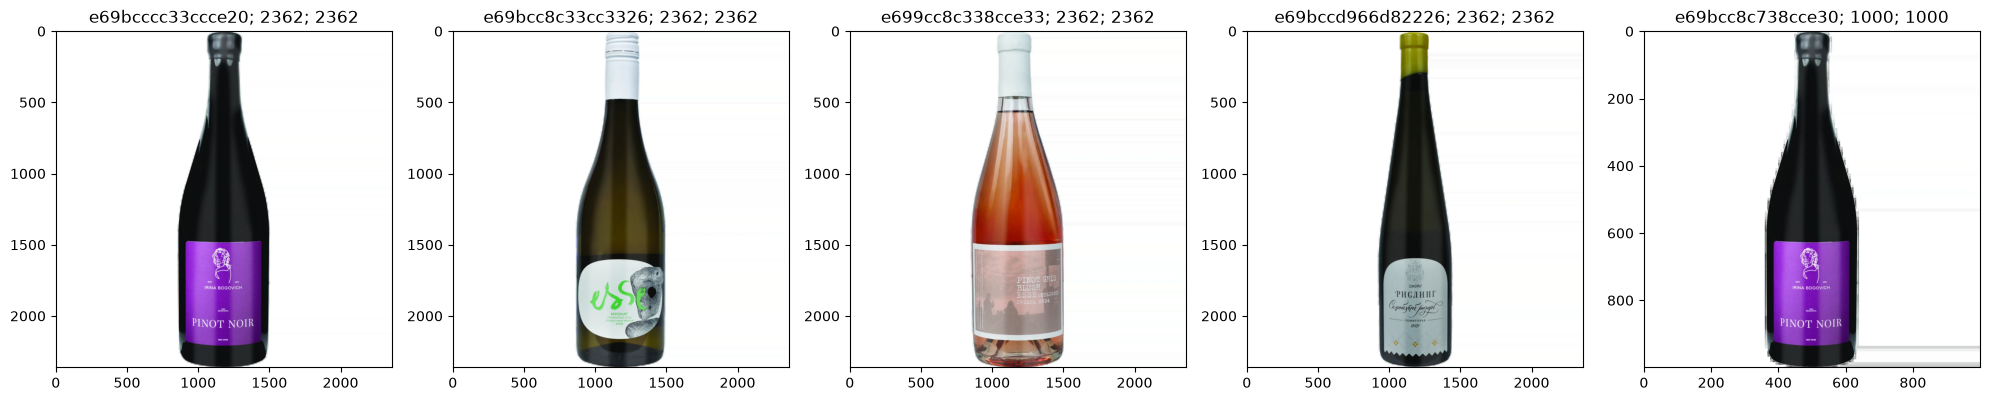

near_01005 27
ax = Axes(0.125,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.285345,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.44569,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.606034,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.766379,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>


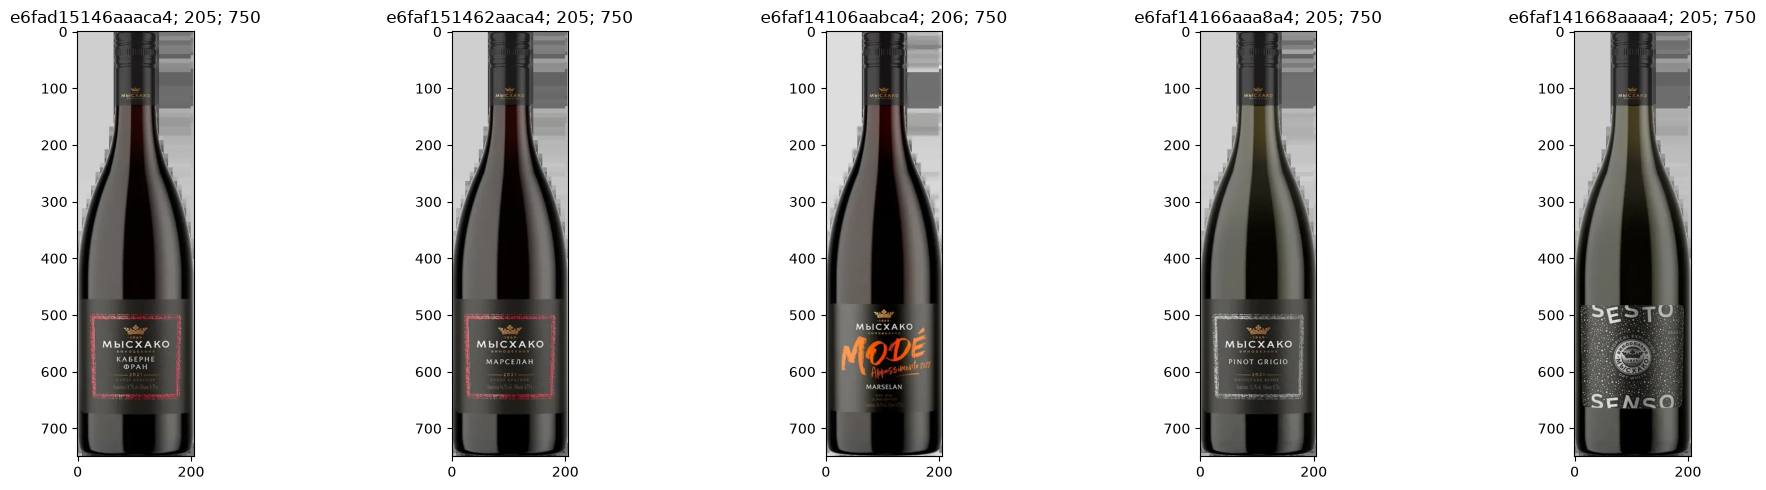

near_00077 21
ax = Axes(0.125,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.285345,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.44569,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.606034,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.766379,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>


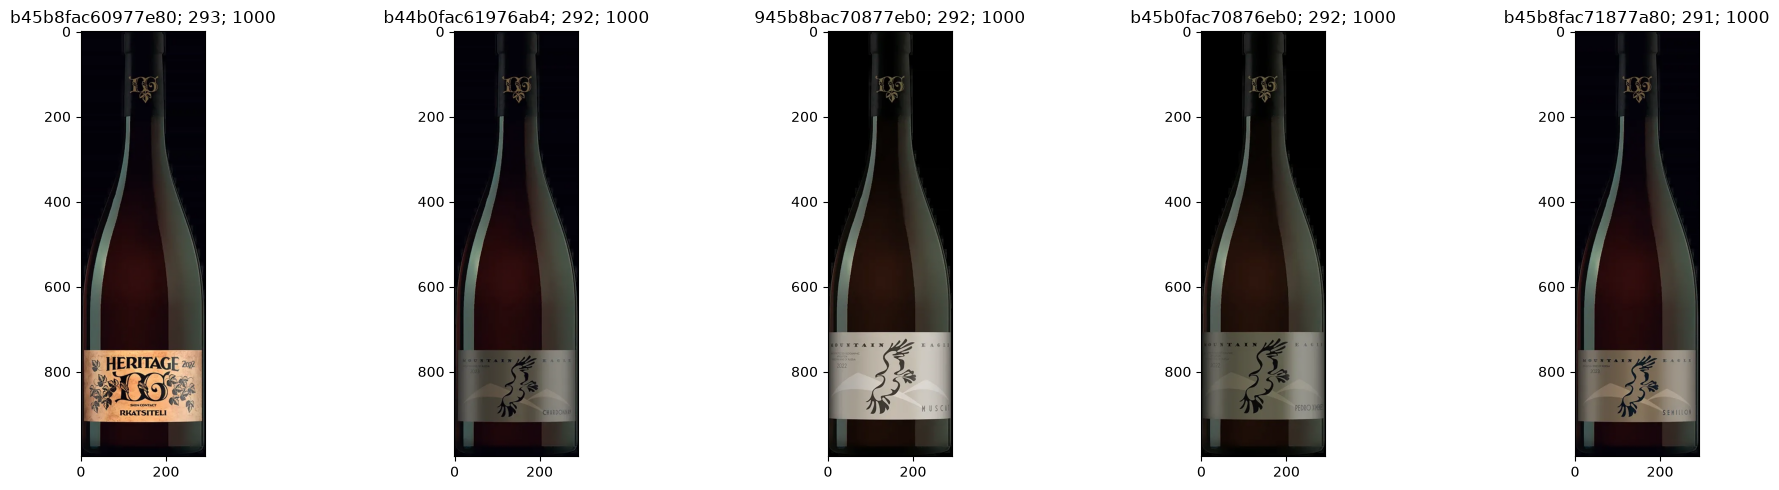

near_01214 20
ax = Axes(0.125,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.285345,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.44569,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.606034,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.766379,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>


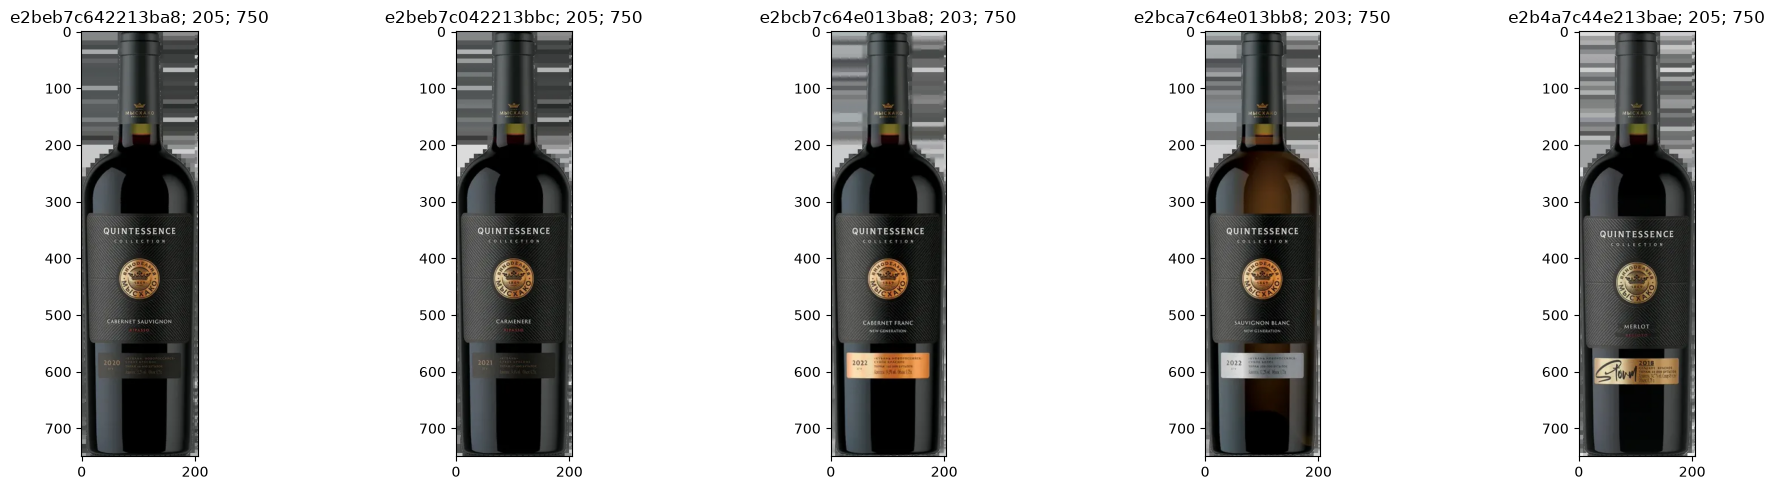

near_00059 19
ax = Axes(0.125,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.285345,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.44569,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.606034,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.766379,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>


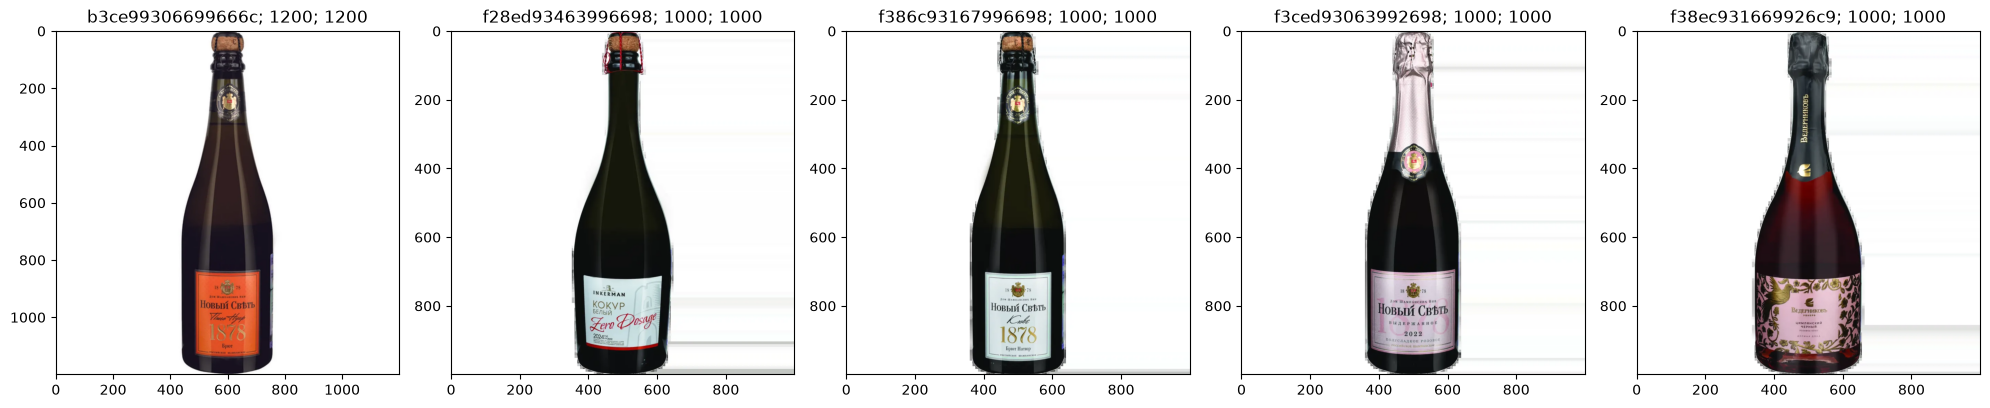

near_01040 19
ax = Axes(0.125,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.285345,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.44569,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.606034,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.766379,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>


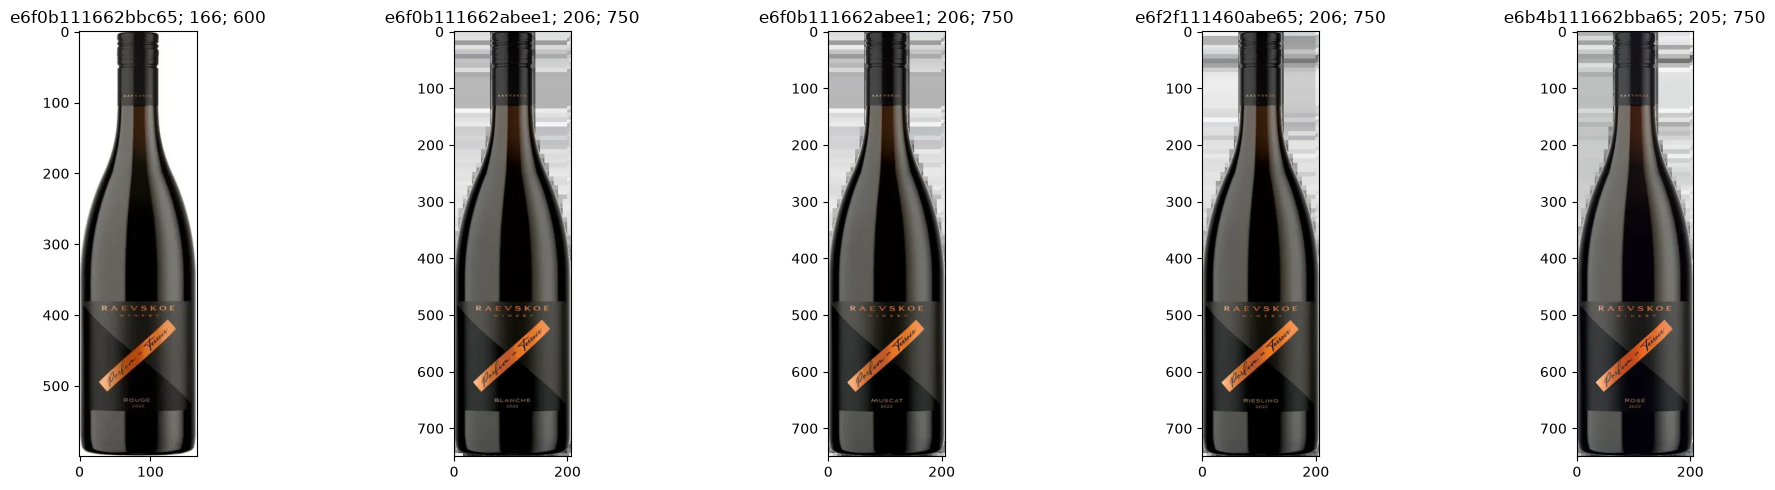

near_01173 18
ax = Axes(0.125,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.285345,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.44569,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.606034,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.766379,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>


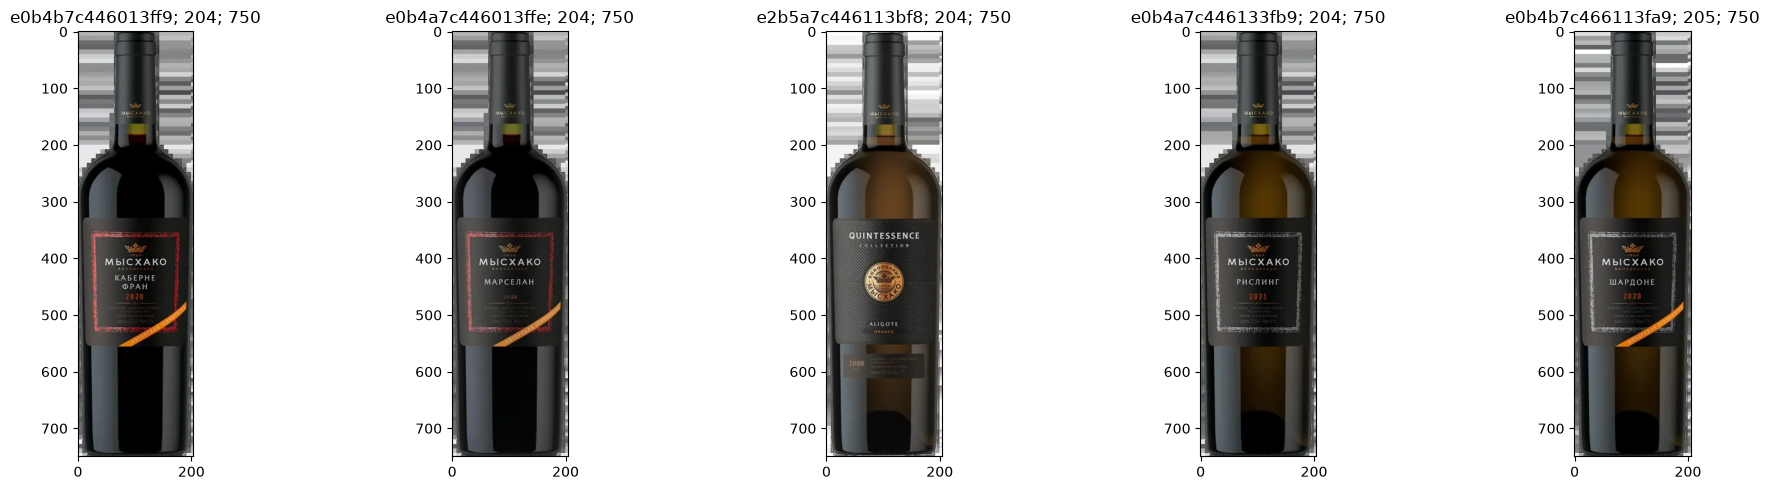

near_01151 17
ax = Axes(0.125,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.285345,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.44569,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.606034,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.766379,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>


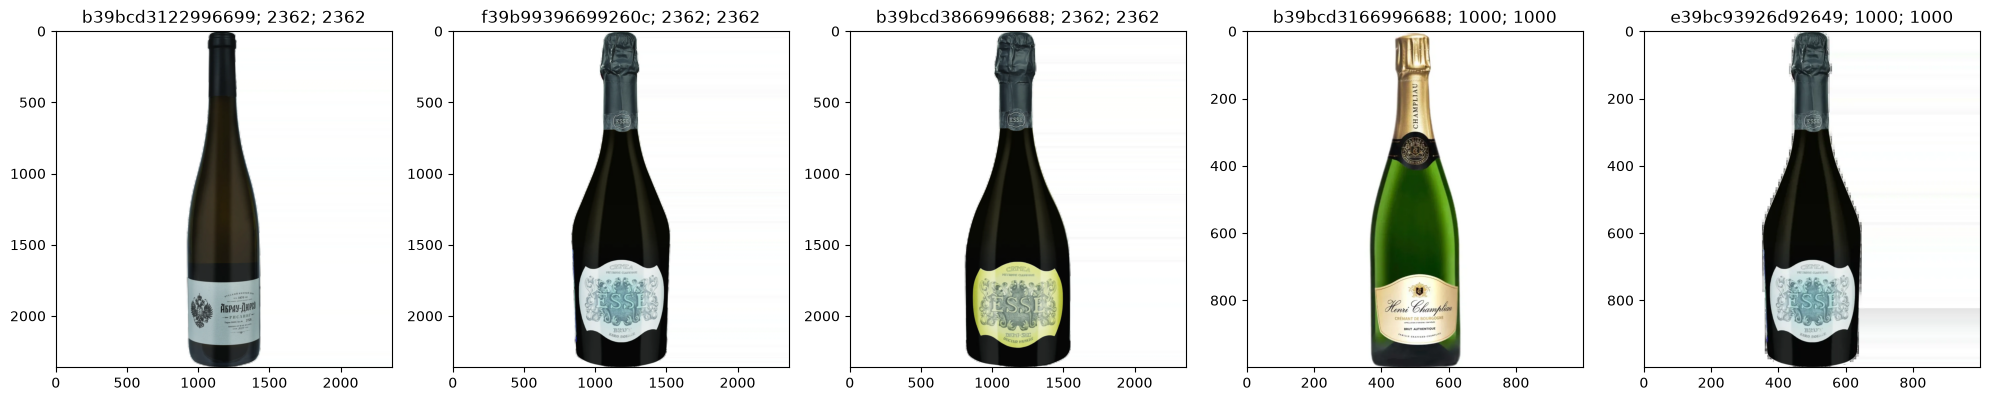

near_00716 16
ax = Axes(0.125,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.285345,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.44569,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.606034,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.766379,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>


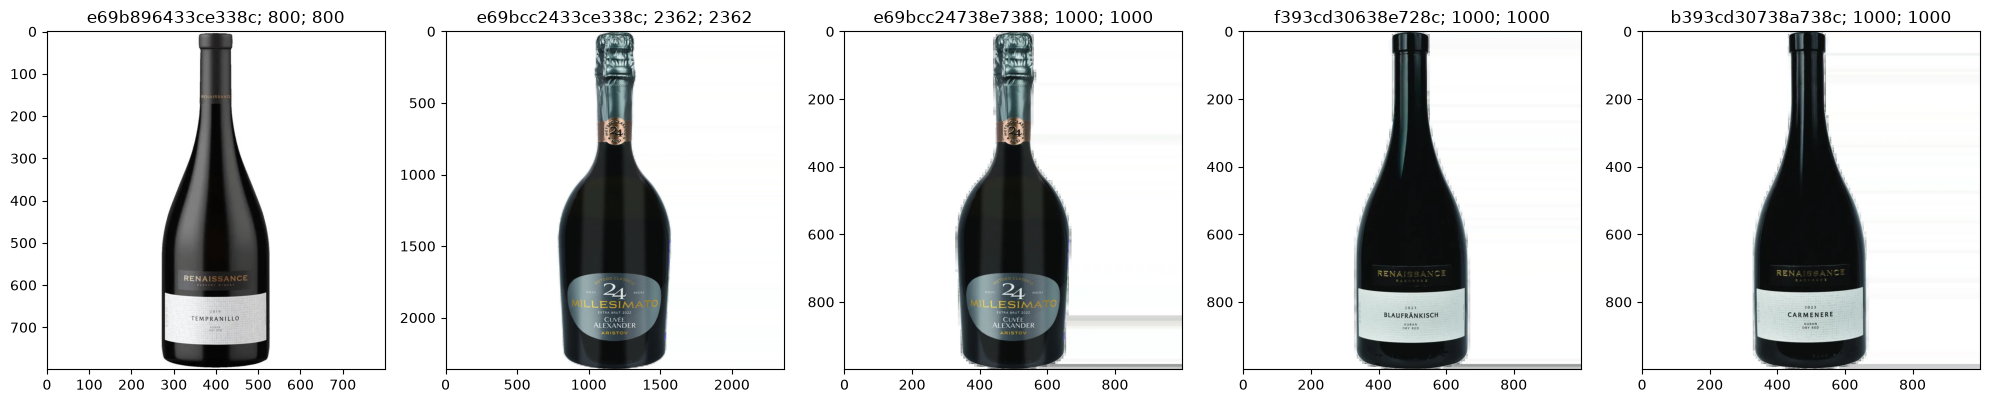

near_00214 15
ax = Axes(0.125,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.285345,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.44569,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.606034,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>
ax = Axes(0.766379,0.11;0.133621x0.77); type(ax) = <class 'matplotlib.axes._axes.Axes'>


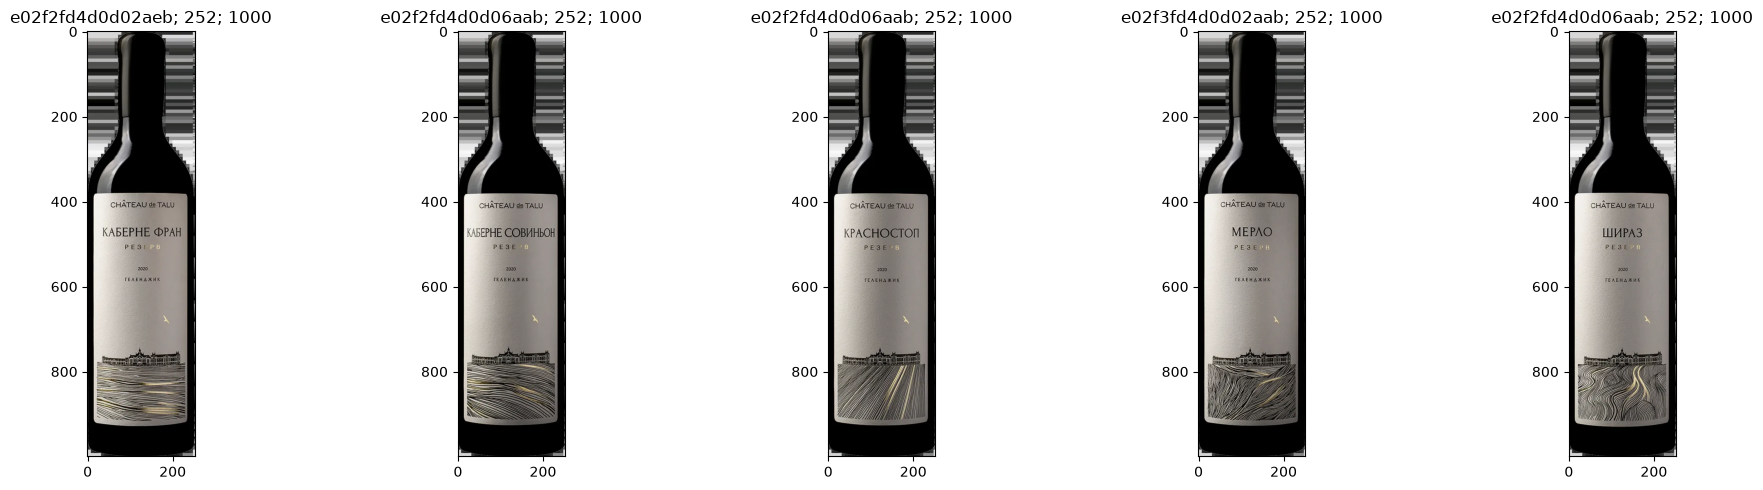

In [98]:
for cluster_id in (cluster_sizes.head(10).index):
    print(cluster_id, cluster_sizes[cluster_id])
    show_near_cluster(cluster_id, max_images=5)

In [99]:
df['is_near_representative'] = True
near_group = df_unique[df_unique['is_near_duplicate'].groupby('near_duplicate_cluster')]
near_group

KeyError: 'near_duplicate_cluster'

In [67]:
# def show_neighbours_image(row, data_dir, max_size=1000):
#     path = data_dir / Path(row['file_path'])
#     img = cv2.imread(str(path))
#     h, w = img.shape[:2]
#     x1 = int(row['x1'])
#     y1 = int(row['y1'])
#     x2 = int(row['x2'])
#     y2 = int(row['y2'])
#     cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), max(2, int(w / 500)))
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#     scale = min(1.0, max_size / max(h, w))
#     plt.figure(figsize=(w * scale / 100, h * scale / 100))
#     plt.imshow(img)
#     plt.show

In [35]:
model = YOLO("yolo26l.pt")
bottle_class = 39
yolo_conf = 0.25
yolo_imgsz = 640
batch = 16
device = 0

In [19]:
df_unique["full_path"] = (df_unique["file_path"].apply(lambda x: data_dir / Path(x)))
print(df_unique["full_path"].head())

0     C:\project\data-scanner\0007_99434f8774.webp
1     C:\project\data-scanner\0011_8961f2de4f.webp
2     C:\project\data-scanner\0015_c1e37f7ee1.webp
3    C:\project\data-scanner\00169_dce952d8a3.webp
4    C:\project\data-scanner\001_1_4171b0b864.webp
Name: full_path, dtype: object


In [20]:
summary_rows = []
detection_rows = []

In [44]:
chunk_size = 256

for start in tqdm(range(0, len(df_unique), chunk_size), desc="YOLO chunks"):
    chunk_df = df_unique.iloc[start:start + chunk_size]
    chunk_paths = [str(path) for path in chunk_df["full_path"]]

    results = model.predict(
        source=chunk_paths,
        classes=[bottle_class],
        conf=yolo_conf,
        imgsz=yolo_imgsz,
        batch=batch,
        device=device,
        quantize=16,
        verbose=False,
    )

    for (_, row), result in zip(chunk_df.iterrows(), results):
        boxes = result.boxes

        if boxes is None or len(boxes) == 0:
            summary_rows.append({
                "hash_sha256": row["hash_sha256"],
                "is_bottle": False,
                "bottle_count": 0,
                "bottle_conf": 0.0,
                "bottle_x1": None,
                "bottle_y1": None,
                "bottle_x2": None,
                "bottle_y2": None,
            })
            continue

        confs = (boxes.conf.detach().cpu().numpy())
        coords = (boxes.xyxy.detach().cpu().numpy())
        best_idx = int(np.argmax(confs))
        best_conf = float(confs[best_idx])
        best_box = coords[best_idx]
        x1, y1, x2, y2 = (best_box.tolist())
        summary_rows.append({
            "hash_sha256": row["hash_sha256"],
            "is_bottle": True,
            "bottle_count": len(boxes),
            "bottle_conf": best_conf,
            "bottle_x1": int(x1),
            "bottle_y1": int(y1),
            "bottle_x2": int(x2),
            "bottle_y2": int(y2),
        })

        for detection_id, (conf, box) in enumerate(zip(confs, coords)):
            x1, y1, x2, y2 = box.tolist()
            detection_rows.append({
                "hash_sha256": row["hash_sha256"],
                "detection_id": detection_id,
                "confidence": float(conf),
                "x1": int(x1),
                "y1": int(y1),
                "x2": int(x2),
                "y2": int(y2),
                "bbox_width": int(x2 - x1),
                "bbox_height": int(y2 - y1),
                "bbox_area": int((x2 - x1) * (y2 - y1)),
            })

yolo_summary = pd.DataFrame(
    summary_rows
)

yolo_detections = pd.DataFrame(
    detection_rows
)

YOLO chunks: 100%|██████████| 34/34 [22:55<00:00, 40.46s/it]


In [46]:
yolo_detections.to_csv('yolo_detections.csv', index=False)
yolo_summary.to_csv('yolo_summary.csv', index=False)

In [22]:
yolo_detections = pd.read_csv(data_dir / 'yolo_detections.csv')
yolo_summary = pd.read_csv(data_dir / 'yolo_summary.csv')

In [23]:
yolo_detections

,hash_sha256,detection_id,confidence,x1,y1,x2,y2,bbox_width,bbox_height,bbox_area
0,c45df88dc7df42ad6249b6b59480728f3da3b773e8bd65...,0,0.762207,6207,2788,6322,3145,115,356,41184
1,06c1ed77fce4d25582b13d5255b3d3914ecda75bcd9c73...,0,0.866211,4214,2640,4347,3102,132,461,61363
2,c61613b1d26d7fa9bebced6a7277d86e71e330b2c088eb...,0,0.539062,3913,1244,4003,1546,89,301,26942
3,c61613b1d26d7fa9bebced6a7277d86e71e330b2c088eb...,1,0.462891,4488,2493,4567,2756,78,262,20671
4,c61613b1d26d7fa9bebced6a7277d86e71e330b2c088eb...,2,0.294189,3885,3664,3990,4079,105,414,43548
...,...,...,...,...,...,...,...,...,...,...
9089,5a4bbf1100ecc45a2a42b49a3c40a2ae02abf0696d894c...,9,0.409180,604,293,706,667,102,374,38148
9090,58ada2c2fbbddaf3f103daccb594724eb4438adec4a866...,0,0.339844,352,879,375,955,22,75,1710
9091,58ada2c2fbbddaf3f103daccb594724eb4438adec4a866...,1,0.297363,263,878,287,958,23,79,1904
9092,58ada2c2fbbddaf3f103daccb594724eb4438adec4a866...,2,0.278320,324,878,347,958,22,79,1813
